In [1]:
import pandas as pd
url = "https://docs.google.com/spreadsheets/d/18LQO7KKhV8kQ_rxegxFDAcscKxs5Drii/export?format=csv"
df_ventas = pd.read_csv(url)

In [2]:
print("--- Primeras 10 filas del conjunto de datos ---")
display(df_ventas.head(10))

--- Primeras 10 filas del conjunto de datos ---


,ProductoID,Producto,Categoría,PrecioUnitario
0,1,Manzanas,Frutas,"1,7"
1,2,Peras,Frutas,"2,96"
2,3,Naranjas,Verduras,"1,54"
3,4,Bananas,Verduras,"2,43"
4,5,Manzanas,Verduras,"2,85"
5,6,Peras,Frutas,"4,2"
6,7,Naranjas,Verduras,"3,39"
7,8,Bananas,Frutas,"2,16"
8,9,Manzanas,Verduras,"3,35"
9,10,Peras,Frutas,"3,27"


In [3]:
print("\n--- Información general del DataFrame ---")
df_ventas.info()


--- Información general del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ProductoID      20 non-null     int64
 1   Producto        20 non-null     str  
 2   Categoría       20 non-null     str  
 3   PrecioUnitario  20 non-null     str  
dtypes: int64(1), str(3)
memory usage: 772.0 bytes


In [4]:
print("\n--- Conteo de valores nulos por columna ---")
print(df_ventas.isnull().sum())


--- Conteo de valores nulos por columna ---
ProductoID        0
Producto          0
Categoría         0
PrecioUnitario    0
dtype: int64


In [6]:
df_ventas.head()

,ProductoID,Producto,Categoría,PrecioUnitario
0,1,Manzanas,Frutas,"1,7"
1,2,Peras,Frutas,"2,96"
2,3,Naranjas,Verduras,"1,54"
3,4,Bananas,Verduras,"2,43"
4,5,Manzanas,Verduras,"2,85"


In [7]:
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ProductoID      20 non-null     int64
 1   Producto        20 non-null     str  
 2   Categoría       20 non-null     str  
 3   PrecioUnitario  20 non-null     str  
dtypes: int64(1), str(3)
memory usage: 772.0 bytes


In [9]:
df_ventas.isnull().sum()

ProductoID        0
Producto          0
Categoría         0
PrecioUnitario    0
dtype: int64

Matplotlib is building the font cache; this may take a moment.


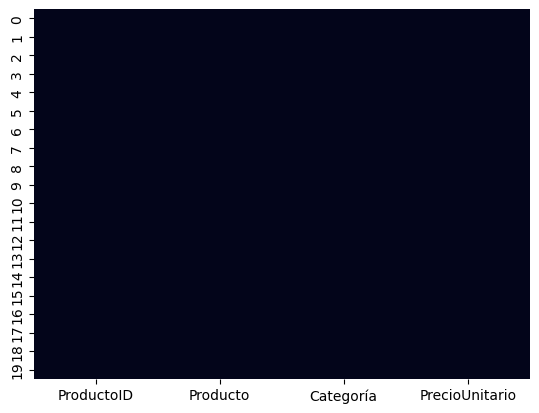

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df_ventas.isnull(), cbar=False)
plt.show()

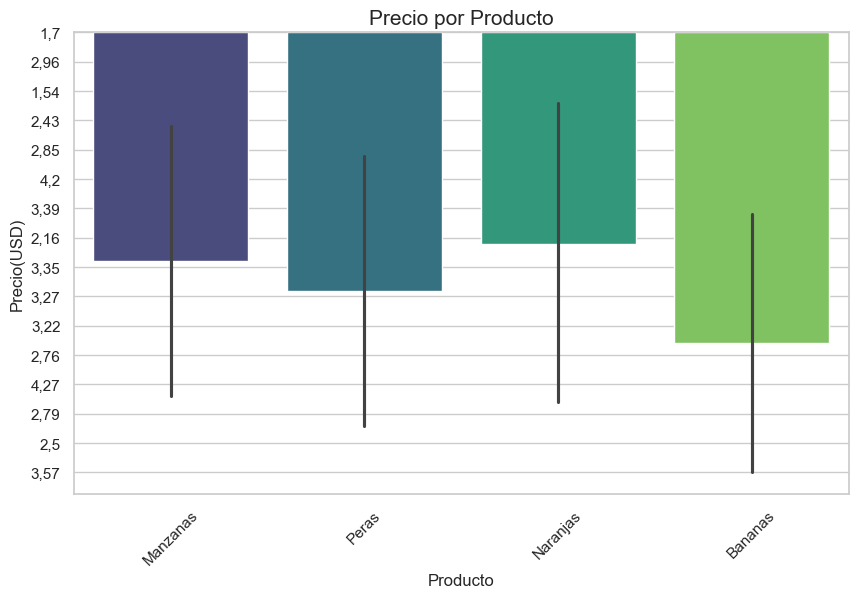

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://docs.google.com/spreadsheets/d/18LQO7KKhV8kQ_rxegxFDAcscKxs5Drii/export?format=csv"
df_ventas = pd.read_csv(url)
# 2. LIMPIEZA (Fundamental para que no dé error de tipo)
df_ventas.columns = df_ventas.columns.str.strip()
if df_ventas['PrecioUnitario'].dtype == 'object':
    df_ventas['PrecioUnitario'] = df_ventas['PrecioUnitario'].str.replace(',', '.').astype(float)
# Grafico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
# Usamos 'hue' para evitar advertencias de versiones nuevas de Seaborn
sns.barplot(x='Producto', y='PrecioUnitario',data=df_ventas, palette='viridis', hue='Producto', legend=False)
plt.title('Precio por Producto',fontsize=15)
plt.xlabel('Producto', fontsize=12)
plt.ylabel('Precio(USD)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [3]:
df_ventas['PrecioUnitario'] = pd.to_numeric(df_ventas['PrecioUnitario'], errors='coerce')

In [16]:
df_ventas.columns = [str(col).strip() for col in df_ventas.columns]

In [17]:
print(f"Las columnas que Python encontró son: {list(df_ventas.columns)}")

Las columnas que Python encontró son: ['ProductoID', 'Producto', 'Categoría', 'PrecioUnitario']


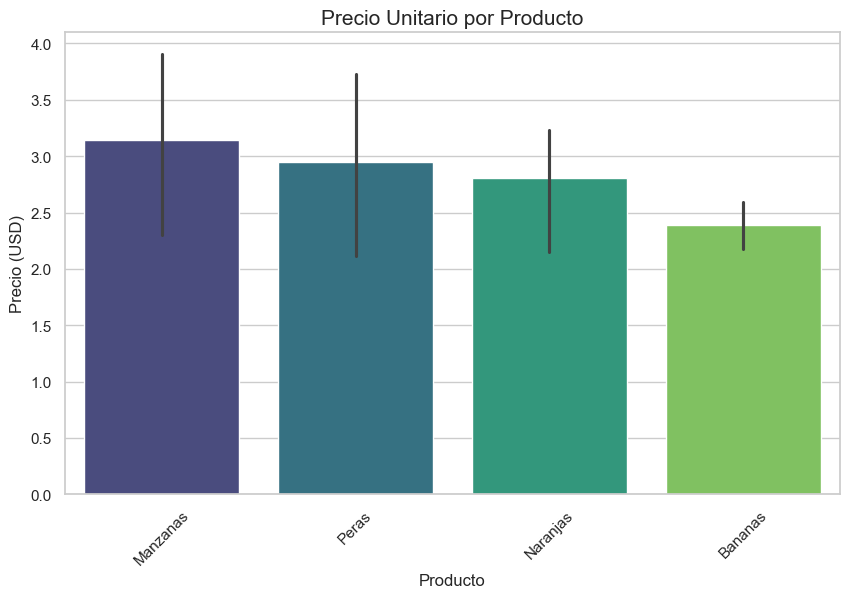

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Aseguramos que los nombres no tengan espacios extra
df_ventas.columns = df_ventas.columns.str.strip()

# 2. Convertimos los precios de "1,71" (texto) a 1.71 (número)
# Primero quitamos la coma por punto, y luego convertimos a float
df_ventas['PrecioUnitario'] = df_ventas['PrecioUnitario'].str.replace(',', '.').astype(float)

# 3. Configuramos el estilo y el gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Usamos los nombres EXACTOS que encontró Python
sns.barplot(data=df_ventas, x='Producto', y='PrecioUnitario', hue='Producto', palette='viridis', legend=False)

# 4. Detalles estéticos
plt.title('Precio Unitario por Producto', fontsize=15)
plt.xlabel('Producto', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.xticks(rotation=45)

plt.show()

La columna ya es numérica, saltando conversión.


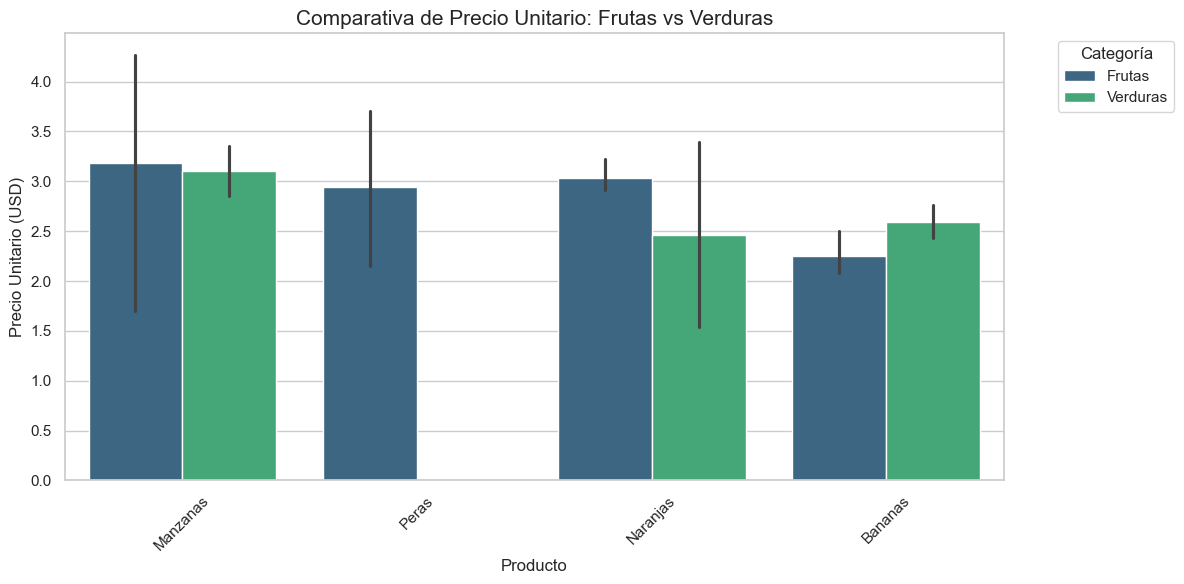

In [20]:
# veremos los precios comparados por Categoría (Frutas vs Verduras)
# Ya que ahi productos que aparecen en ambas categorias.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Limpieza de datos (Limpiar nombres de columnas)
df_ventas.columns = df_ventas.columns.str.strip()
# Convertimos comas a puntos y a flotante para que sea un número real
# df_ventas['PrecioUnitario'] = df_ventas['PrecioUnitario'].str.replace(',', '.').astype(float)

# 2. Conversión inteligente: Solo convierte si es necesario (si es tipo 'object'/texto)
if df_ventas['PrecioUnitario'].dtype == 'object':
    df_ventas['PrecioUnitario'] = df_ventas['PrecioUnitario'].str.replace(',', '.').astype(float)
    print("Conversión de texto a número realizada.")
else:
    print("La columna ya es numérica, saltando conversión.")

# 2. Configuración del gráfico comparativo
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Usamos 'hue' para separar las barras por Categoría (Frutas vs Verduras)
sns.barplot(
    data=df_ventas, 
    x='Producto', 
    y='PrecioUnitario', 
    hue='Categoría', 
    palette='viridis'
)

# 3. Personalización
plt.title('Comparativa de Precio Unitario: Frutas vs Verduras', fontsize=15)
plt.xlabel('Producto', fontsize=12)
plt.ylabel('Precio Unitario (USD)', fontsize=12)
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera del gráfico
plt.xticks(rotation=45)
plt.tight_layout() # Ajusta para que no se corten los nombres

plt.show()

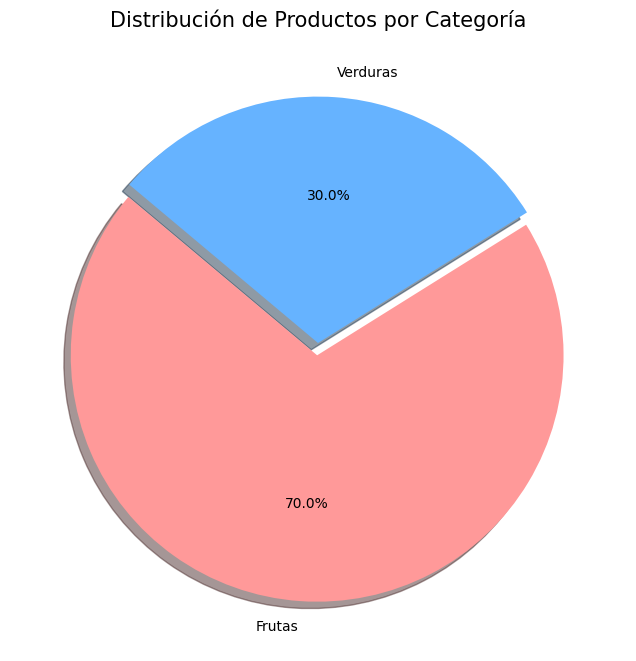

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://docs.google.com/spreadsheets/d/18LQO7KKhV8kQ_rxegxFDAcscKxs5Drii/export?format=csv"
df_ventas = pd.read_csv(url)
df_ventas.columns = df_ventas.columns.str.strip()

# 1. Preparar los datos: Contar cuántos productos hay por categoría
conteo_categorias = df_ventas['Categoría'].value_counts()

# 2. Configurar el gráfico
plt.figure(figsize=(8, 8))
colores = ['#ff9999','#66b3ff'] # Colores suaves (puedes cambiarlos)

# 3. Crear el gráfico de torta
plt.pie(
    conteo_categorias, 
    labels=conteo_categorias.index, 
    autopct='%1.1f%%', # Esto pone el porcentaje con un decimal
    startangle=140,    # Gira el gráfico para que se vea mejor
    colors=colores,
    explode=(0.05, 0),  # "Saca" un poquito la primera tajada para resaltar
    shadow=True         # Le da un toque de profundidad
)

plt.title('Distribución de Productos por Categoría', fontsize=15)
plt.show()

El gráfico de torta (o Pie Chart) es ideal para ver proporciones. En este caso, vamos a ver qué porcentaje de tu lista de productos corresponde a Frutas y cuánto a Verduras.
value_counts(): Es la función mágica de Pandas que cuenta cuántas veces aparece cada categoría.

autopct='%1.1f%%': Este formato le dice a Python: "Calcula el porcentaje automáticamente y muéstralo con un decimal".

explode: Sirve para separar una rebanada de la torta. Es un truco visual muy usado en análisis de datos para llamar la atención sobre un dato específico.

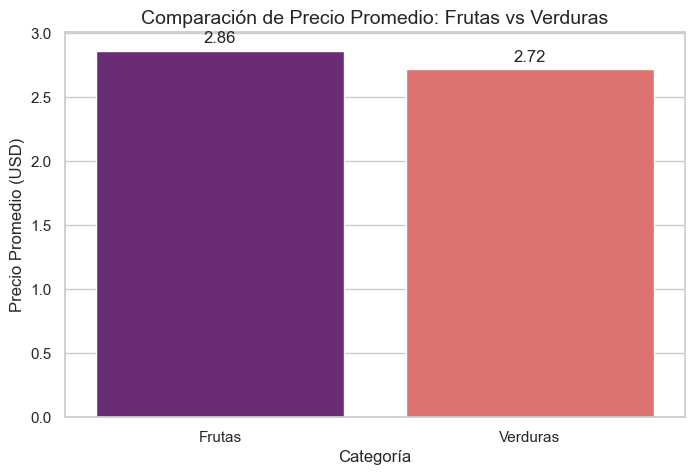

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
url = "https://docs.google.com/spreadsheets/d/18LQO7KKhV8kQ_rxegxFDAcscKxs5Drii/export?format=csv"
df_ventas = pd.read_csv(url)
# 1. Aseguramos que los nombres de columnas no tengan espacios
df_ventas.columns = df_ventas.columns.str.strip()

# 2. Convertimos la columna a numérico
# Primero quitamos posibles espacios, reemplazamos coma por punto y convertimos
df_ventas['PrecioUnitario'] = pd.to_numeric(
    df_ventas['PrecioUnitario'].astype(str).str.replace(',', '.'), 
    errors='coerce'
)

# 3. Calculamos el promedio de precio por cada categoría
# Agrupamos por 'Categoría' y sacamos la media de 'PrecioUnitario'
df_promedios = df_ventas.groupby('Categoría')['PrecioUnitario'].mean().reset_index()

# 4. Configuramos el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 5. Creamos el gráfico
ax = sns.barplot(
    x='Categoría', 
    y='PrecioUnitario', 
    data=df_promedios, 
    palette='magma',
    hue='Categoría',
    legend=False
)

# Añadimos etiquetas de valor sobre las barras para que sea más claro
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Comparación de Precio Promedio: Frutas vs Verduras', fontsize=14)
plt.ylabel('Precio Promedio (USD)')
plt.xlabel('Categoría')
plt.show()

Gráfico de Barras Agrupado o un Boxplot. Esto nos dirá, de un solo vistazo, si en tu negocio es más caro comprar frutas o verduras en promedio.

Para que esto funcione como una verdadera profesional, vamos a usar una función de Pandas llamada .groupby(). Es el "pan de cada día" de un analista de datos.

Usamos .astype(str). Esto convierte cada celda en texto puro para que podamos buscar la coma (,) y cambiarla por punto (.), que es lo que Python entiende como decimal.

errors='coerce': Si por casualidad hay una palabra donde debería haber un número, este comando le dice a Python: "No te rompas, pon un NaN (vacío) y sigue adelante".